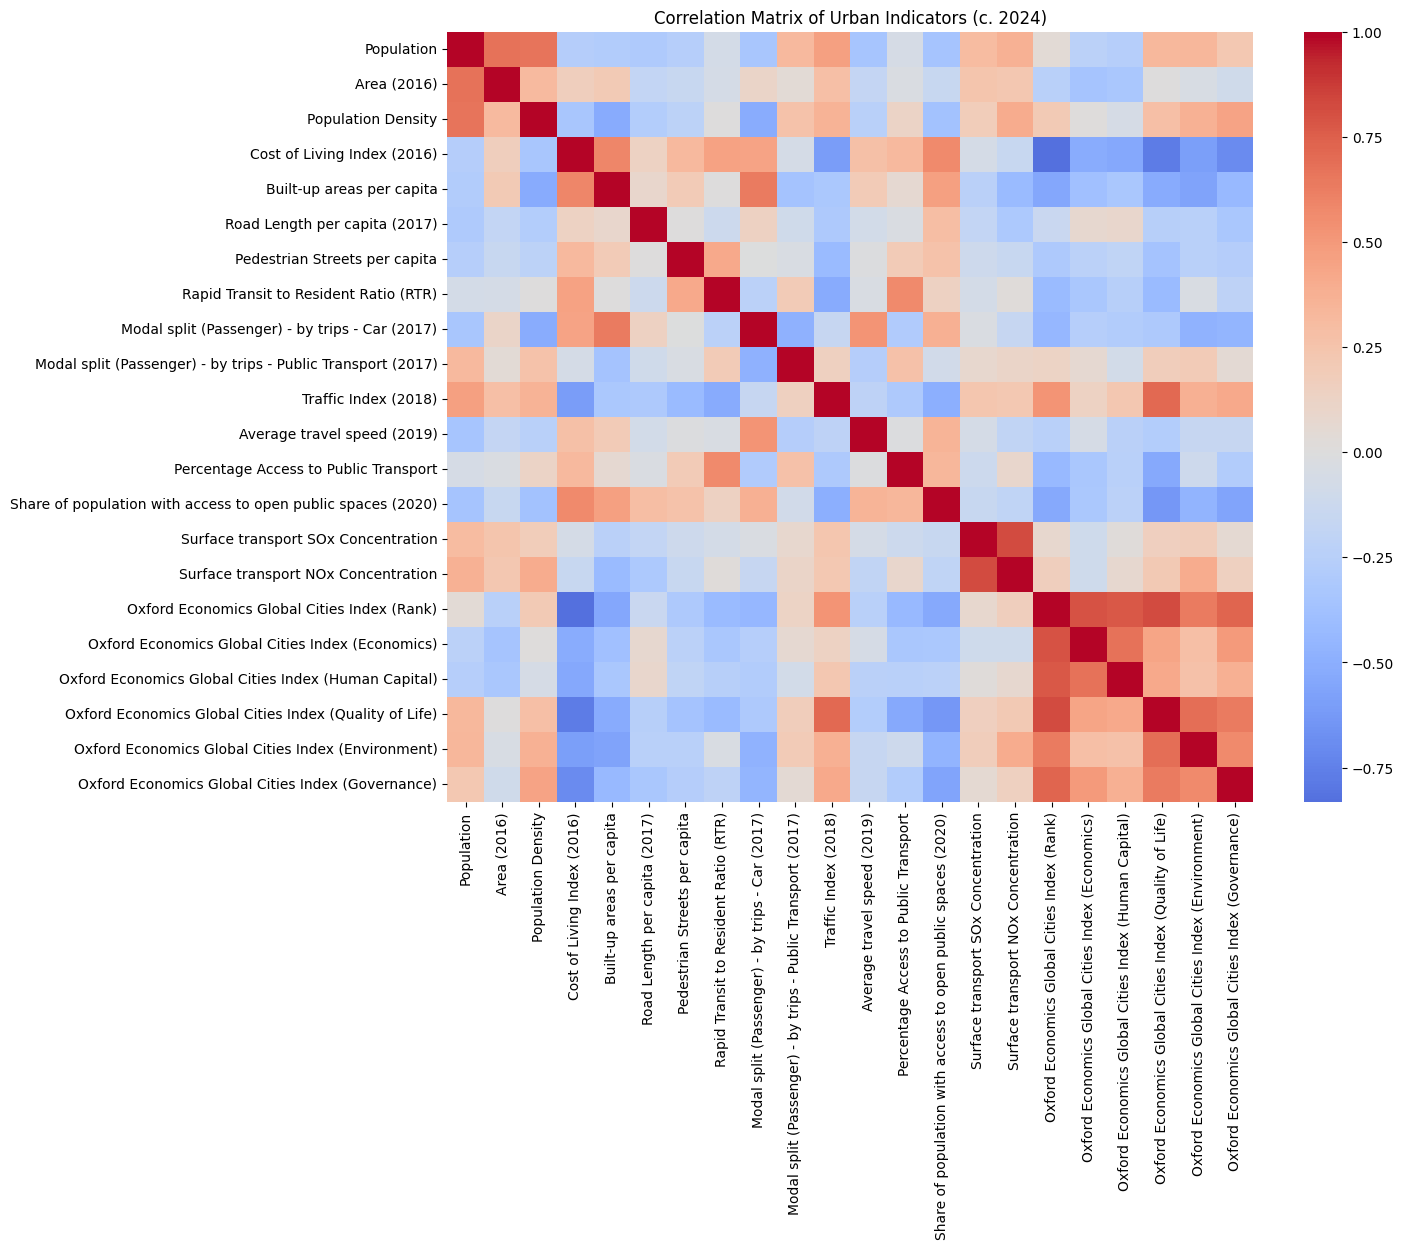

In [644]:
import pandas as pd

df = pd.read_csv('cleaned.csv')
df.set_index('Urban Center', inplace=True)
corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Urban Indicators (c. 2024)")
plt.show()  

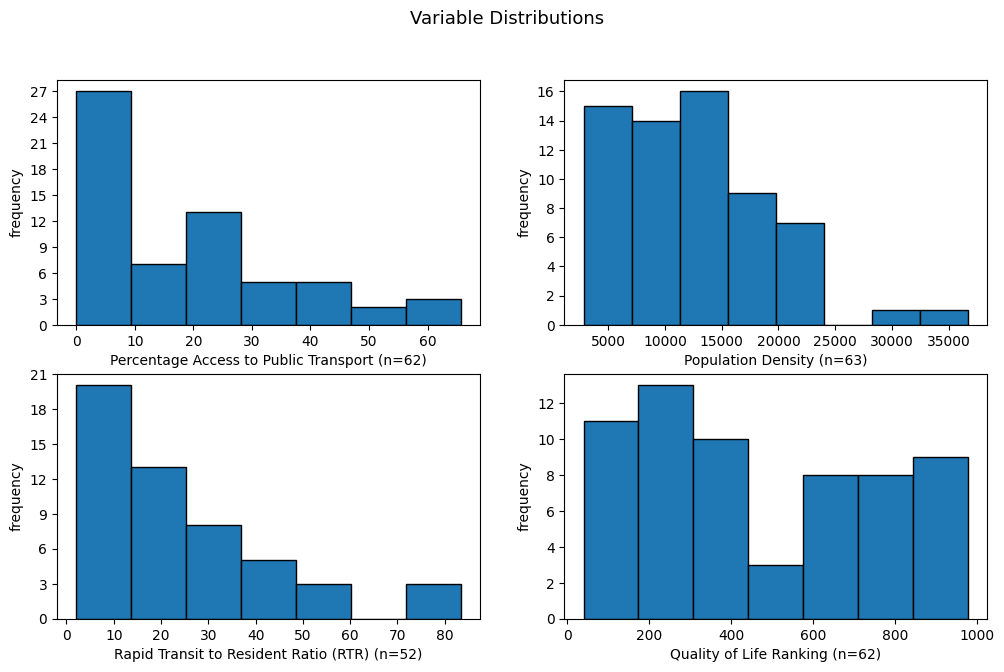

In [645]:
# 1. Study distribution (density, access, rtr, quality of life)
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(2,2, figsize=(12,7))
fig.suptitle('Variable Distributions', fontsize=13)
ax = ax.flatten()

to_plot = ['Percentage Access to Public Transport', 'Population Density', 'Rapid Transit to Resident Ratio (RTR)', 'Oxford Economics Global Cities Index (Quality of Life)']

for i, col in enumerate(to_plot):
    data = df[[col]]
    cleaned = data.dropna().copy()
    if col == 'Percentage Access to Public Transport':
        cleaned['Percentage Access to Public Transport'] *= 100
    
    ax[i].hist(cleaned, bins='auto', edgecolor='black')
    if col!='Oxford Economics Global Cities Index (Quality of Life)':
        ax[i].set_xlabel(f"{col} (n={cleaned.shape[0]})")
    else:
        ax[i].set_xlabel(f"Quality of Life Ranking (n={cleaned.shape[0]})")
    ax[i].set_ylabel('frequency')

    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))

# Most variables appear left-skewed, except quality-of-life rankings.
# Density is mostly found within 25,000 person / sqkm
# Access to public transport has strong modal representation for <10% (access is generally low)
# Higher RTR is less observed, possibly due to large public expenditure to build them
# Most cities in dataset are in top 500 ranking

Text(0, 0.5, 'Quality of Life Ranking')

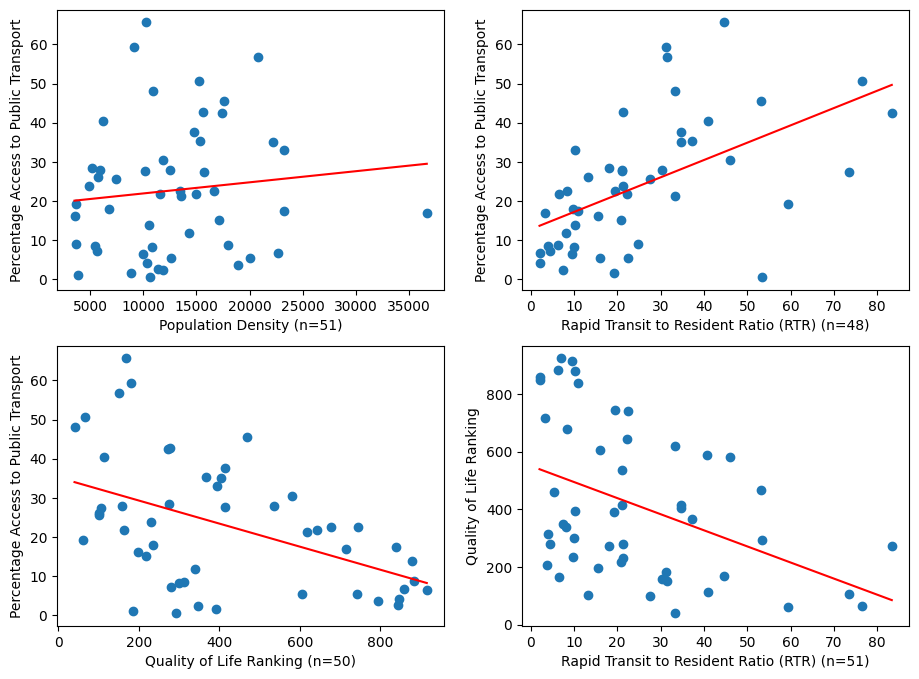

In [ ]:
# 2a. How does access relate with other variables?
import statsmodels.api as sm
import numpy as np

data = df[to_plot].copy()
data.loc[:,'Percentage Access to Public Transport'] = data.loc[:,'Percentage Access to Public Transport'].replace(0, np.nan)
data['Percentage Access to Public Transport'] *= 100

fig, ax = plt.subplots(2,2,figsize=(11,8))
ax = ax.flatten()

for i, col in enumerate(data.columns):
    if col=='Percentage Access to Public Transport':
        continue
    
    subset_cleaned = data[['Percentage Access to Public Transport', col]].dropna()
    X = subset_cleaned[[col]]
    X = sm.add_constant(X)
    y = subset_cleaned['Percentage Access to Public Transport']
    model = sm.OLS(y, X).fit()
    X_sorted = sm.add_constant(X.sort_values(by=col))
    y_line = model.predict(X_sorted)

    ax[i-1].scatter(subset_cleaned[col], subset_cleaned['Percentage Access to Public Transport'])
    ax[i-1].plot(X_sorted[col], y_line, color='red')

    ax[i-1].set_ylabel('Percentage Access to Public Transport')
    if col=='Oxford Economics Global Cities Index (Quality of Life)':
        ax[i-1].set_xlabel(f"Quality of Life Ranking (n={subset_cleaned.shape[0]})")
    else:
        ax[i-1].set_xlabel(f"{col} (n={subset_cleaned.shape[0]})")

# 2b. Is quality of life associated with rapid transit infrastructure?

subset_cleaned = data[['Rapid Transit to Resident Ratio (RTR)', 'Oxford Economics Global Cities Index (Quality of Life)']].dropna()
X = subset_cleaned[['Rapid Transit to Resident Ratio (RTR)']]
X = sm.add_constant(X)
y = subset_cleaned['Oxford Economics Global Cities Index (Quality of Life)']
model = sm.OLS(y, X).fit()
X_sorted = sm.add_constant(X.sort_values(by='Rapid Transit to Resident Ratio (RTR)'))
y_line = model.predict(X_sorted)

ax[3].scatter(subset_cleaned['Rapid Transit to Resident Ratio (RTR)'], subset_cleaned['Oxford Economics Global Cities Index (Quality of Life)'])
ax[3].plot(X_sorted['Rapid Transit to Resident Ratio (RTR)'], y_line, color='red')
ax[3].set_xlabel(f'Rapid Transit to Resident Ratio (RTR) (n={subset_cleaned.shape[0]})')
ax[3].set_ylabel('Quality of Life Ranking')

# ax[0]: Relationship appears approximately linear though heteroscedascity may exist
# ax[1]: Large variance in higher RTR (have to check for outliers / large influencers)
# ax[2], ax[3]: Variance decreases overall. Lower RTR tend to have more diverse city representations in terms of quality of life  

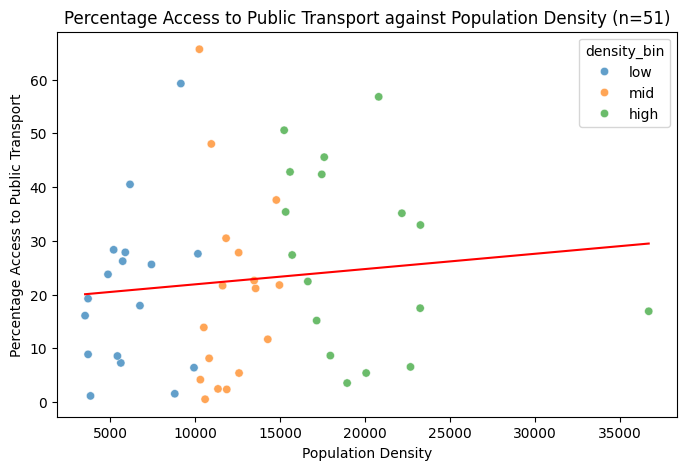

LM p value: 0.5672
F p value: 0.5829
Levene p value: 0.6239
R-squared (access ~ density): 0.012453479850215166


In [ ]:
# 3a. Visualise access ~ density (separate by group)
from statsmodels.stats.diagnostic import het_white

den_acc_pt = data[['Population Density', 'Percentage Access to Public Transport', 'Rapid Transit to Resident Ratio (RTR)']]
cleaned = den_acc_pt.dropna(subset=['Population Density', 'Percentage Access to Public Transport']).copy()

X = cleaned[['Population Density']]
X = sm.add_constant(X)
y = cleaned['Percentage Access to Public Transport']

model = sm.OLS(y, X).fit()
X_sorted = sm.add_constant(X.sort_values(by='Population Density'))
y_line = model.predict(X_sorted)

cleaned['density_bin'] = pd.qcut(cleaned['Population Density'], q=3, labels=['low', 'mid', 'high'])

low = cleaned[cleaned['density_bin'] == 'low']['Percentage Access to Public Transport']
mid = cleaned[cleaned['density_bin'] == 'mid']['Percentage Access to Public Transport']
high = cleaned[cleaned['density_bin'] == 'high']['Percentage Access to Public Transport']

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=cleaned, x='Population Density', y='Percentage Access to Public Transport', hue='density_bin', alpha=0.7)
ax.plot(X_sorted['Population Density'], y_line, color='red')
ax.set_xlabel('Population Density')
ax.set_ylabel('Percentage Access to Public Transport')
ax.set_title(f'Percentage Access to Public Transport against Population Density (n={cleaned.shape[0]})')

plt.show()

# 3b. Test for significant difference in variance of residues (White's test)
lm, lm_p, f, f_p = het_white(model.resid, model.model.exog)
print(f"LM p value: {lm_p:.4f}") 
print(f"F p value: {f_p:.4f}")

# 3c. Test for difference in variance between groups (Levene's test)
from scipy.stats import levene

stat, p = levene(low, mid, high)
print(f"Levene p value: {p:.4f}")

# 3d. R squared (access ~ density)
print(f"R-squared (access ~ density): {model.rsquared}")

# Insufficient evidence from white test and Levine test for heteroscedascity (all p > 0.05). 
# Low R squared indicates density cannot adequately explain public transport access

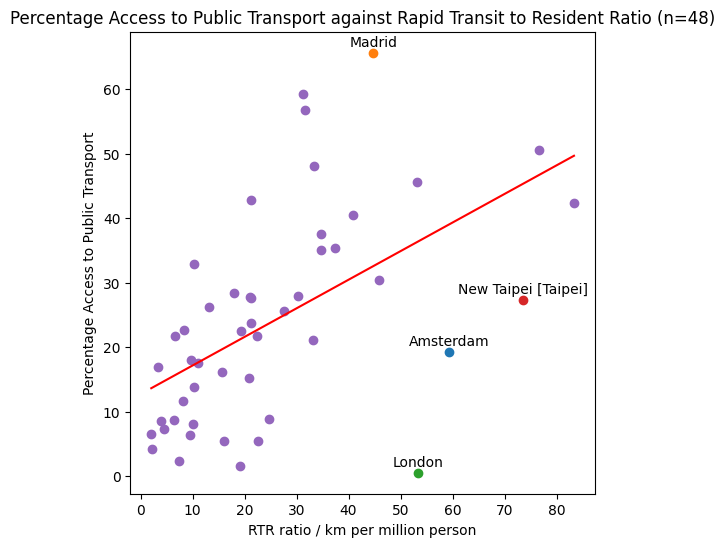

R-squared (access ~ RTR): 0.2948


In [ ]:
## 4a. Fit a line using OLS (Access ~ RTR)
from statsmodels.stats.outliers_influence import OLSInfluence

# n=48
cleaned = den_acc_pt.dropna(subset=['Percentage Access to Public Transport', 'Rapid Transit to Resident Ratio (RTR)'])

X = sm.add_constant(cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y = cleaned[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()
sorted_cleaned = cleaned.sort_values(by='Rapid Transit to Resident Ratio (RTR)')
X_sorted = sm.add_constant(sorted_cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y_line = model.predict(X_sorted)

# Find anomalous points using Cook's distance
influence = OLSInfluence(model)
(c, p) = influence.cooks_distance

threshold = 4/len(cleaned.index)
anomaly = cleaned[c > threshold]
non_anomaly = cleaned[~(c > threshold)]

# 4b. Scatter plot (access vs RTR) + OLS plot
fig, ax = plt.subplots(figsize=(6,6))
for city, row in anomaly.iterrows():
    ax.scatter(row.iloc[2], row.iloc[1])
    ax.text(row.iloc[2], row.iloc[1]+1, city, ha='center')

ax.scatter(non_anomaly['Rapid Transit to Resident Ratio (RTR)'], non_anomaly['Percentage Access to Public Transport'])
ax.plot(sorted_cleaned['Rapid Transit to Resident Ratio (RTR)'], y_line, color='red')

ax.set_title(f"Percentage Access to Public Transport against Rapid Transit to Resident Ratio (n={cleaned.shape[0]})")
ax.set_xlabel("RTR ratio / km per million person")
ax.set_ylabel("Percentage Access to Public Transport")
plt.show()

# R squared (access ~ RTR)
print(f"R-squared (access ~ RTR): {model.rsquared:.4f}")

# RTR ratio moves with percentage access, with a few outliers indicating 
# some cities are unusually efficient (high access + low RTR ratio), or inefficient (low access + high RTR ratio)
# Outcome might depend more on systematic planning or its results (quality of life)

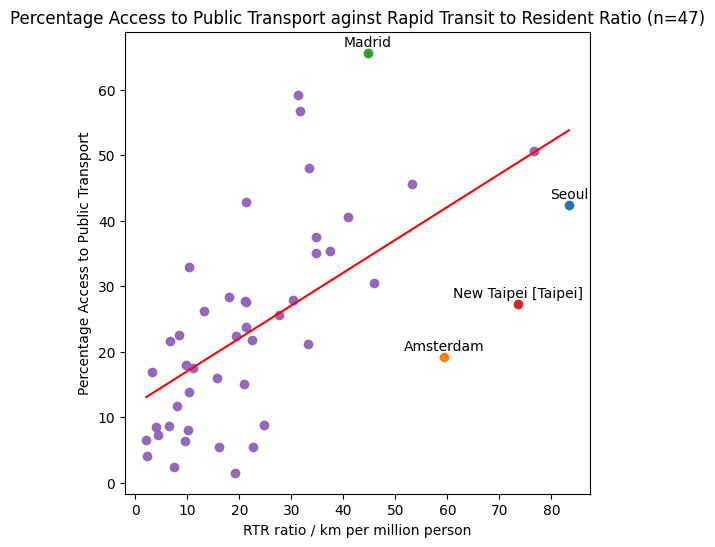

R-squared (access ~ RTR): 0.3773


In [ ]:
# Drop London (suspected data irregularity, ~0 PT access inconsistent with expectations)
cleaned = cleaned.drop('London')

# 4c. REPEAT flagging anomalous points + plot regression

X = sm.add_constant(cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y = cleaned[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()
sorted_cleaned = cleaned.sort_values(by='Rapid Transit to Resident Ratio (RTR)')
X_sorted = sm.add_constant(sorted_cleaned[['Rapid Transit to Resident Ratio (RTR)']])
y_line = model.predict(X_sorted)

influence = OLSInfluence(model)
(c, p) = influence.cooks_distance

threshold = 4/len(cleaned.index)
anomaly = cleaned[c > threshold]
non_anomaly = cleaned[~(c > threshold)]

# Plot scatter
fig, ax = plt.subplots(figsize=(6,6))
for city, row in anomaly.iterrows():
    ax.scatter(row.iloc[2], row.iloc[1])
    ax.text(row.iloc[2], row.iloc[1]+1, city, ha='center')

ax.scatter(non_anomaly['Rapid Transit to Resident Ratio (RTR)'], non_anomaly['Percentage Access to Public Transport'])
ax.plot(sorted_cleaned['Rapid Transit to Resident Ratio (RTR)'], y_line, color='red')

ax.set_title(f"Percentage Access to Public Transport aginst Rapid Transit to Resident Ratio (n={cleaned.shape[0]})")
ax.set_xlabel("RTR ratio / km per million person")
ax.set_ylabel("Percentage Access to Public Transport")
plt.show()

# R squared (access ~ RTR)
print(f"R-squared (access ~ RTR): {model.rsquared:.4f}")

# Anomalous points are the same, with Seoul as an addition (n=4). 
# Model generalises better (29% - 37%) when erroneous value is removed


In [ ]:
# 5a. Do cities with lower relative access to public transport rank lower in quality of life? (using access residues) 
   
# Stratify cities (access below OLS, access above OLS)
cleaned['residual_acc'] = cleaned['Percentage Access to Public Transport']-model.predict(X)

# Right join to include only cities in previous iteration of 'cleaned'
df_join = df[['Pedestrian Streets per capita', 'Modal split (Passenger) - by trips - Car (2017)', 
              'Oxford Economics Global Cities Index (Quality of Life)', 'Oxford Economics Global Cities Index (Governance)']]
cleaned = df_join.join(cleaned, how='right')

cleaned['group'] = ['Above expected' if r>0 else 'Below expected' for r in cleaned['residual_acc']]
cleaned.dropna(subset=['Oxford Economics Global Cities Index (Quality of Life)'], inplace=True)

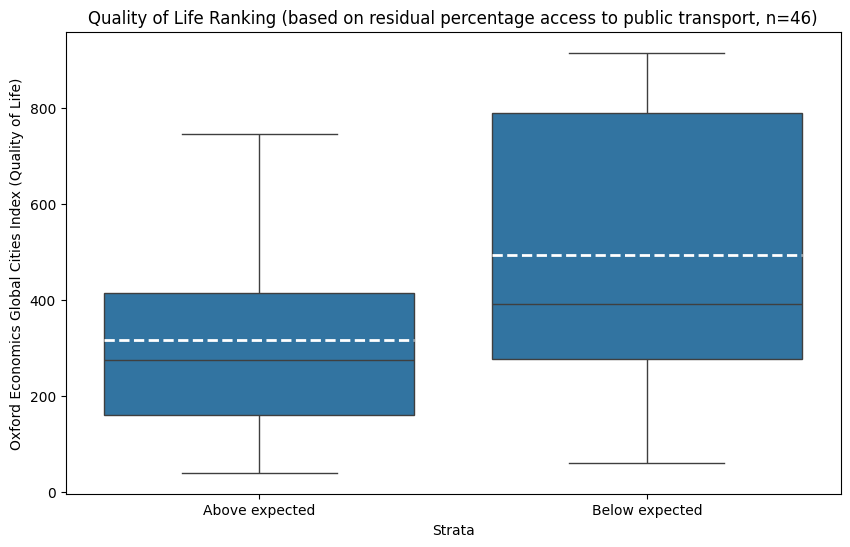

Var(above expected): 40836.20037807184
Var(below expected): 80447.70510396975


In [ ]:
# 5b. Explore governance score (rank) in both strata

fig, ax = plt.subplots(figsize=(10,6))

# Boxplot for both strata
sns.boxplot(data=cleaned, x='group', y='Oxford Economics Global Cities Index (Quality of Life)', 
            showmeans=True, meanline=True, meanprops={'color': 'white', 'lw': 2})
ax.set_title(f'Quality of Life Ranking (based on residual percentage access to public transport, n={cleaned.shape[0]})')
ax.set_xlabel('Strata')
plt.show()

print(f"Var(above expected): {np.var(cleaned[cleaned['group']=='Above expected']['Oxford Economics Global Cities Index (Quality of Life)'])}")
print(f"Var(below expected): {np.var(cleaned[cleaned['group']=='Below expected']['Oxford Economics Global Cities Index (Quality of Life)'])}")

# Cities above expected access line tend to have overall higher rank 
# The lowest ranking (outlier disregarded) is the upper bound of bottom 25% of its counterpart 

# Cities below expected access line have higher variance (x2), implying some highly livable cities rely on a transport landscape that does not necessarily involve public transport
# This also suggests systematic factors in lower ranking cities that results in lower transport access
# Both boxplots show overall high within-group variance

# Despite lower median (<300) in cities above OLS line, the bottom 50% of the cities vary greatly in ranking with rankings reaching 700+
# This could suggest strong institutional support for efficient urban mobility that operates on necessity, often common in hyper-dense developing cities with lower systemic quality of life

In [ ]:
# 5c. Mann-Whitney U Test 
from scipy import stats

above = cleaned[cleaned['group']== 'Above expected']['Oxford Economics Global Cities Index (Quality of Life)']
below = cleaned[cleaned['group']== 'Below expected']['Oxford Economics Global Cities Index (Quality of Life)']

u, p = stats.mannwhitneyu(above, below)
print(f"Mann-Whitney P-value: {p:.4f}")
print(f"U statistic: {u}")
print()

# 5d. Welch T test
t, p = stats.ttest_ind(above, below, equal_var=False)
print(f"T test p value: {p:.4f}")
print(f"t statistic: {t:.4f}")
print()

# 5e. Effect Size
m1 = above.mean()
m2 = below.mean()
n1 = above.shape[0]
n2 = below.shape[0]

s1, s2 = above.var(ddof=1), below.var(ddof=1)
std = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
d = (m1-m2)/std
print(f"Cohen d: {d:.4f}")

# Mann-Whitney U Test exhibits moderate evidence in difference between rankings of both strata 
# Result of this non-parametric test is not dependent on normally distributed data
# Welch t test results show high significance in difference of means of rankings, suggesting urban livability as a strong driver 
# for public transportation accessibility 

# Moderate effect size (|d|=0.69) of quality of life between cities above OLS and below OLS regimes. 
# Technically speaking, the mean ranking of two strata vary by 0.69 std 

# Statistical tests in exploratory data, however, are not confirmatory or inferential.

Mann-Whitney P-value: 0.0506
U statistic: 175.0

T test p value: 0.0231
t statistic: -2.3640

Cohen d: -0.6971


In [ ]:
# 6a. To what extent do density, RTR and quality of life contribute to variation in access to public transport? (multivariate regression)

cleaned['rtr_norm'] = (cleaned['Rapid Transit to Resident Ratio (RTR)']-cleaned['Rapid Transit to Resident Ratio (RTR)'].mean())/cleaned['Rapid Transit to Resident Ratio (RTR)'].std()
cleaned['den_norm'] = (cleaned['Population Density']-cleaned['Population Density'].mean())/cleaned['Population Density'].std()
cleaned['qol_norm'] = (cleaned['Oxford Economics Global Cities Index (Quality of Life)']-cleaned['Oxford Economics Global Cities Index (Quality of Life)'].mean())/cleaned['Oxford Economics Global Cities Index (Quality of Life)'].std()
X = sm.add_constant(cleaned[['den_norm', 'rtr_norm', 'qol_norm']])
y = cleaned[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()

print(model.summary())

# OLS model explains almost 50% of variation of public transport access. 

                                      OLS Regression Results                                     
Dep. Variable:     Percentage Access to Public Transport   R-squared:                       0.495
Model:                                               OLS   Adj. R-squared:                  0.459
Method:                                    Least Squares   F-statistic:                     13.70
Date:                                   Fri, 01 May 2026   Prob (F-statistic):           2.26e-06
Time:                                           23:50:51   Log-Likelihood:                -176.82
No. Observations:                                     46   AIC:                             361.6
Df Residuals:                                         42   BIC:                             369.0
Df Model:                                              3                                         
Covariance Type:                               nonrobust                                         
                 coe

In [ ]:
# 6b. Robustness test (exclude high influential cities)

influence = OLSInfluence(model)
(c, p) = influence.cooks_distance

threshold = 4/len(cleaned.index)
anomaly = cleaned[c > threshold]
non_anomaly = cleaned[~(c > threshold)]
print(anomaly.index)

# Plot regression without anomaly
X = sm.add_constant(non_anomaly[['den_norm', 'rtr_norm', 'qol_norm']])
y = non_anomaly[['Percentage Access to Public Transport']]
model = sm.OLS(y, X).fit()

print(model.summary())

# Exclulding highly influential cities improves stability of the linear relationship
# This also suggests the linear model is sensitive to systemic differences in governance 
# However, density p value shooting up to 10% indicates its low predicitve ability

# Validation should follow in larger samples to confirm this hypothesis. Nonetheless, metrics are stable and statistically significant.

Index(['Hong Kong', 'Amsterdam', 'Madrid', 'New Taipei [Taipei]'], dtype='object', name='Urban Center')
                                      OLS Regression Results                                     
Dep. Variable:     Percentage Access to Public Transport   R-squared:                       0.599
Model:                                               OLS   Adj. R-squared:                  0.568
Method:                                    Least Squares   F-statistic:                     18.96
Date:                                   Fri, 01 May 2026   Prob (F-statistic):           1.11e-07
Time:                                           23:50:51   Log-Likelihood:                -152.57
No. Observations:                                     42   AIC:                             313.1
Df Residuals:                                         38   BIC:                             320.1
Df Model:                                              3                                         
Covariance Typ